In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
SampleName = "BULK_QC_12TP_K562_EL4"

In [3]:
timetagdf = pd.read_table(SampleName+".aligned.sorted.merged.tagged.time_tags.csv", sep = "\t")
human_df=pd.read_table(SampleName+".aligned.sorted.merged.tagged.HUMAN_ONLY.dge.txt.gz")
human_vector=human_df.iloc[:,1:].sum()
mouse_df=pd.read_table(SampleName+".aligned.sorted.merged.tagged.MOUSE_ONLY.dge.txt.gz")
mouse_vector=mouse_df.iloc[:,1:].sum()

In [4]:
type(human_vector)

pandas.core.series.Series

In [5]:
human_transcript_df = pd.DataFrame({'CELL BARCODES':human_vector.index, 'HUMAN_COUNTS':human_vector.values})
display(human_transcript_df)
mouse_transcript_df = pd.DataFrame({'CELL BARCODES':mouse_vector.index, 'MOUSE_COUNTS':mouse_vector.values})
display(mouse_transcript_df)
combined_transcript_df = human_transcript_df.merge(mouse_transcript_df, on='CELL BARCODES')
display(combined_transcript_df)

,CELL BARCODES,HUMAN_COUNTS
0,CTGTCTCTTATA,57
1,TGTCTCTTATAC,15
2,TTTATCTCCTTA,4494
3,CCGGCCCTCGTC,68
4,ATGCTTGGTTTG,86
...,...,...
39995,AATTATCTGAAC,0
39996,CGGCCCAATCAG,1
39997,CTGAAACTTGGC,0
39998,TGCTTTGGACGG,67


,CELL BARCODES,MOUSE_COUNTS
0,CTGTCTCTTATA,50
1,TGTCTCTTATAC,11
2,TTTATCTCCTTA,84
3,CCGGCCCTCGTC,3315
4,ATGCTTGGTTTG,3942
...,...,...
39995,AATTATCTGAAC,1
39996,CGGCCCAATCAG,0
39997,CTGAAACTTGGC,12
39998,TGCTTTGGACGG,2


,CELL BARCODES,HUMAN_COUNTS,MOUSE_COUNTS
0,CTGTCTCTTATA,57,50
1,TGTCTCTTATAC,15,11
2,TTTATCTCCTTA,4494,84
3,CCGGCCCTCGTC,68,3315
4,ATGCTTGGTTTG,86,3942
...,...,...,...
39995,AATTATCTGAAC,0,1
39996,CGGCCCAATCAG,1,0
39997,CTGAAACTTGGC,0,12
39998,TGCTTTGGACGG,67,2


In [6]:
timetagdf

,CELL BARCODES,TIME TAG COUNTS,FINAL TIME TAG,SEQ1_TTGG,SEQ2_CCTT,SEQ3_GGAA,SEQ4_TTCC,SEQ5_TTAA,SEQ6_TTTT,SEQ7_CCAA,SEQ8_CCGG,SEQ9_CCCC,SEQ10_GGTT,SEQ11_GGCC,SEQ12_GGGG
0,CGCGTATTTAAA,33,SEQ4_TTCC,0,0,0,31,0,0,0,0,0,0,2,0
1,ATCTCAAGACCA,425,SEQ3_GGAA,0,0,423,0,0,0,0,0,0,0,0,2
2,AACCGACATTTT,124,SEQ7_CCAA,0,0,0,1,0,0,123,0,0,0,0,0
3,CGCATACGTGAA,167,SEQ11_GGCC,0,0,2,0,0,0,0,0,0,0,165,0
4,CTGGAGATGCCG,491,SEQ9_CCCC,0,0,0,0,0,0,2,0,489,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56808,CAATTGAACCAA,27,SEQ10_GGTT,0,0,0,0,0,0,0,0,0,27,0,0
56809,ATCCCAGGGCAC,54,SEQ12_GGGG,0,0,0,0,0,0,0,0,0,0,0,54
56810,CCATAAGAACTT,21,SEQ2_CCTT,0,21,0,0,0,0,0,0,0,0,0,0
56811,AATGAGCCGCGC,24,SEQ8_CCGG,0,0,0,0,0,0,0,24,0,0,0,0


In [7]:
timetagdf=timetagdf[~timetagdf["FINAL TIME TAG"].str.contains("Collision Detected")] #Removing Cell Barcodes with Collision in Time-Tag Determination

In [8]:
Combined_df_for_plot = timetagdf.merge(combined_transcript_df, on = "CELL BARCODES")
#Combined_df_for_plot["BARCODES BELONGS"] = Combined_df_for_plot[['HUMAN_COUNTS', 
 #                                 'MOUSE_COUNTS']].idxmax(axis=1)
Combined_df_for_plot

,CELL BARCODES,TIME TAG COUNTS,FINAL TIME TAG,SEQ1_TTGG,SEQ2_CCTT,SEQ3_GGAA,SEQ4_TTCC,SEQ5_TTAA,SEQ6_TTTT,SEQ7_CCAA,SEQ8_CCGG,SEQ9_CCCC,SEQ10_GGTT,SEQ11_GGCC,SEQ12_GGGG,HUMAN_COUNTS,MOUSE_COUNTS
0,ATCTCAAGACCA,425,SEQ3_GGAA,0,0,423,0,0,0,0,0,0,0,0,2,245,9
1,AACCGACATTTT,124,SEQ7_CCAA,0,0,0,1,0,0,123,0,0,0,0,0,502,6
2,CGCATACGTGAA,167,SEQ11_GGCC,0,0,2,0,0,0,0,0,0,0,165,0,132,1
3,CTGGAGATGCCG,491,SEQ9_CCCC,0,0,0,0,0,0,2,0,489,0,0,0,201,6
4,TTCCTACACAAC,639,SEQ11_GGCC,0,0,1,4,0,0,0,1,0,0,633,0,277,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34377,GGGATGACTTAT,38,SEQ8_CCGG,1,0,0,0,0,0,0,37,0,0,0,0,1,58
34378,GCACTTGCGAAT,70,SEQ4_TTCC,0,0,0,70,0,0,0,0,0,0,0,0,1,62
34379,TAGAAGAATTGT,75,SEQ6_TTTT,1,0,0,0,0,73,0,0,0,1,0,0,0,89
34380,ACTTATATTTCG,24,SEQ2_CCTT,0,24,0,0,0,0,0,0,0,0,0,0,0,8


In [9]:
Combined_df_for_plot["FINAL TIME TAG"].value_counts()

SEQ1_TTGG     3598
SEQ3_GGAA     3436
SEQ4_TTCC     3036
SEQ2_CCTT     2953
SEQ11_GGCC    2906
SEQ9_CCCC     2892
SEQ5_TTAA     2870
SEQ10_GGTT    2769
SEQ7_CCAA     2713
SEQ8_CCGG     2545
SEQ6_TTTT     2364
SEQ12_GGGG    2300
Name: FINAL TIME TAG, dtype: int64

In [10]:
Combined_df_for_plot[["CELL BARCODES","FINAL TIME TAG","HUMAN_COUNTS","MOUSE_COUNTS"]].to_csv("Species_Mixing_data.time_tags.csv",index=False)

Total beads: 34382
Number of time tags: 12
Time tags (SEQ1-SEQ12 order): ['SEQ1_TTGG', 'SEQ2_CCTT', 'SEQ3_GGAA', 'SEQ4_TTCC', 'SEQ5_TTAA', 'SEQ6_TTTT', 'SEQ7_CCAA', 'SEQ8_CCGG', 'SEQ9_CCCC', 'SEQ10_GGTT', 'SEQ11_GGCC', 'SEQ12_GGGG']
Grid layout: 3 rows x 4 cols


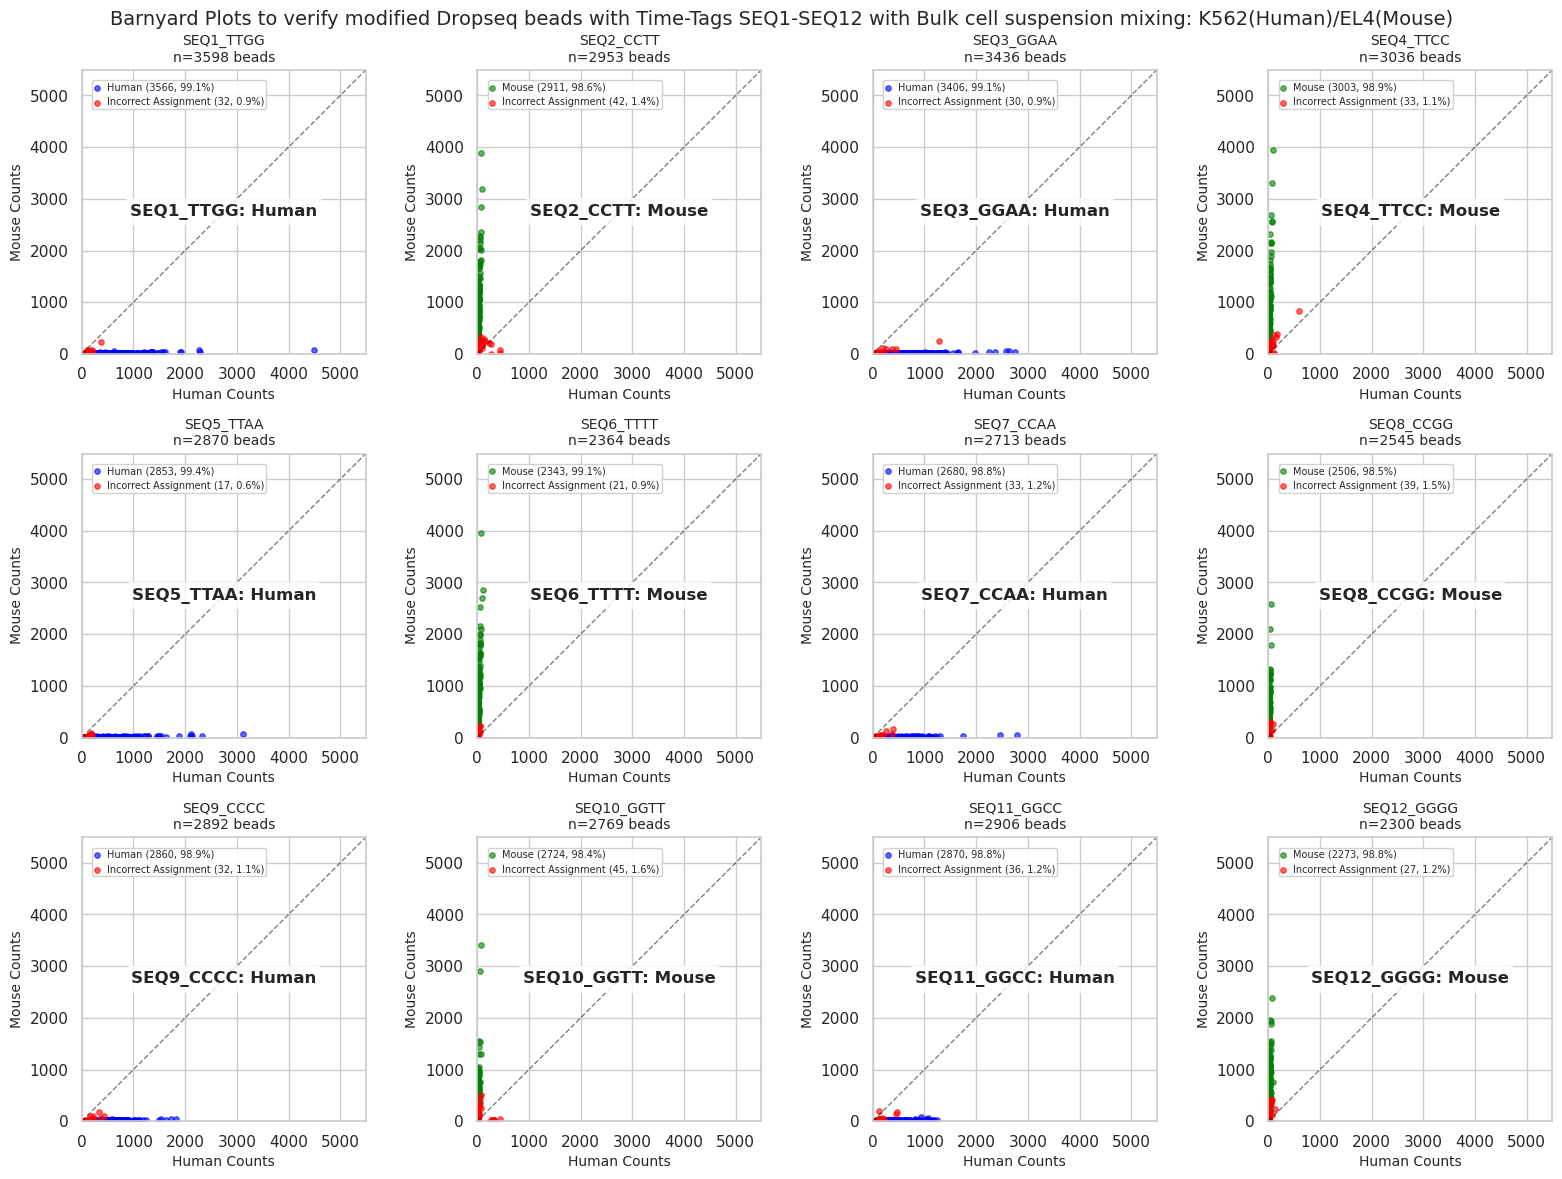

Creating individual SVG plots in 'individual_time_tag_plots' directory...
Saved: individual_time_tag_plots/SEQ1_TTGG.svg
Saved: individual_time_tag_plots/SEQ2_CCTT.svg
Saved: individual_time_tag_plots/SEQ3_GGAA.svg
Saved: individual_time_tag_plots/SEQ4_TTCC.svg
Saved: individual_time_tag_plots/SEQ5_TTAA.svg
Saved: individual_time_tag_plots/SEQ6_TTTT.svg
Saved: individual_time_tag_plots/SEQ7_CCAA.svg
Saved: individual_time_tag_plots/SEQ8_CCGG.svg
Saved: individual_time_tag_plots/SEQ9_CCCC.svg
Saved: individual_time_tag_plots/SEQ10_GGTT.svg
Saved: individual_time_tag_plots/SEQ11_GGCC.svg
Saved: individual_time_tag_plots/SEQ12_GGGG.svg
\nSummary by time tag (SEQ1-SEQ12 order, strict purity: only >=90% pure in majority tags, else incorrect assignment):
SEQ1_TTGG (Human):
  Total beads: 3598
  Category counts: {'human': 3566, 'incorrect_assignment': 32}
SEQ2_CCTT (Mouse):
  Total beads: 2953
  Category counts: {'mouse': 2911, 'incorrect_assignment': 42}
SEQ3_GGAA (Human):
  Total beads: 343

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set publication-quality style
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)  # Reduced font scale for subplots

# Load the data
df = pd.read_csv('Species_Mixing_data.time_tags.csv')

# Compute total transcripts
df['TOTAL_TRANSCRIPTS'] = df['HUMAN_COUNTS'] + df['MOUSE_COUNTS']

print(f"Total beads: {len(df)}")

# Standard categorization function (for non-majority tags, using 90% threshold for purity)
def categorize_cell_standard(row):
    total = row['TOTAL_TRANSCRIPTS']
    human = row['HUMAN_COUNTS']
    mouse = row['MOUSE_COUNTS']
    human_prop = human / total if total > 0 else 0
    mouse_prop = mouse / total if total > 0 else 0
    
    # Pure human (>=90%)
    if human_prop >= 0.90:
        return 'human'  # Blue
    # Pure mouse (>=90%)
    elif mouse_prop >= 0.90:
        return 'mouse'  # Green
    else:
        return 'incorrect_assignment'  # Red (includes mixed and opposite species)

# Tag-specific categorization functions for majority tags (strict: only pure if >=90%, else incorrect)
def categorize_human_majority(row):
    total = row['TOTAL_TRANSCRIPTS']
    human = row['HUMAN_COUNTS']
    mouse = row['MOUSE_COUNTS']
    human_prop = human / total if total > 0 else 0
    mouse_prop = mouse / total if total > 0 else 0
    
    # For human-majority tag: pure human only if >=90% human (mouse <=10%)
    if human_prop >= 0.90:
        return 'human'  # Blue
    else:
        return 'incorrect_assignment'  # Red (any >10% mouse, including mixed and opposite species)

def categorize_mouse_majority(row):
    total = row['TOTAL_TRANSCRIPTS']
    human = row['HUMAN_COUNTS']
    mouse = row['MOUSE_COUNTS']
    human_prop = human / total if total > 0 else 0
    mouse_prop = mouse / total if total > 0 else 0
    
    # For mouse-majority tag: pure mouse only if >=90% mouse (human <=10%)
    if mouse_prop >= 0.90:
        return 'mouse'  # Green
    else:
        return 'incorrect_assignment'  # Red (any >10% human, including mixed and opposite species)

# Create color map
color_map = {'human': 'blue', 'mouse': 'green', 'incorrect_assignment': 'red'}

# Get unique time tags and sort them numerically by SEQ number
unique_tags_raw = df['FINAL TIME TAG'].unique()
unique_tags = sorted(unique_tags_raw, key=lambda x: int(x.split('_')[0][3:]))
n_tags = len(unique_tags)

print(f"Number of time tags: {n_tags}")
print("Time tags (SEQ1-SEQ12 order):", unique_tags)

# Calculate subplot layout (aim for roughly square grid)
n_cols = int(np.ceil(np.sqrt(n_tags)))
n_rows = int(np.ceil(n_tags / n_cols))

print(f"Grid layout: {n_rows} rows x {n_cols} cols")

# Create the figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

# Flatten axes array for easier indexing if we have multiple rows/cols
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# Calculate global axis limits for consistency across all panels
max_count = max(df['HUMAN_COUNTS'].max(), df['MOUSE_COUNTS'].max())
axis_limit = max_count + 1000

# Plot each time tag in a separate panel (in SEQ1-SEQ12 order)
for i, tag in enumerate(unique_tags):
    ax = axes[i]
    
    # Filter data for this time tag (all beads)
    tag_data = df[df['FINAL TIME TAG'] == tag]
    total_beads = len(tag_data)
    
    # Determine majority species for this tag (>90% proportion using standard categorization)
    tag_with_standard = tag_data.copy()
    tag_with_standard['CATEGORY'] = tag_with_standard.apply(categorize_cell_standard, axis=1)
    standard_counts = tag_with_standard['CATEGORY'].value_counts()
    human_base = standard_counts.get('human', 0)
    mouse_base = standard_counts.get('mouse', 0)
    
    human_prop_base = human_base / total_beads
    mouse_prop_base = mouse_base / total_beads
    
    if human_prop_base > 0.90:
        dominant_species = 'Human'
        # Apply strict human-majority categorization
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_human_majority, axis=1)
    elif mouse_prop_base > 0.90:
        dominant_species = 'Mouse'
        # Apply strict mouse-majority categorization
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_mouse_majority, axis=1)
    else:
        dominant_species = 'Mixed'
        # Use standard categorization
        tag_with_cat = tag_with_standard.copy()
    
    category_counts = tag_with_cat['CATEGORY'].value_counts()
    human_count = category_counts.get('human', 0)
    mouse_count = category_counts.get('mouse', 0)
    incorrect_count = category_counts.get('incorrect_assignment', 0)
    
    human_label = f'Human ({human_count}, {human_count/total_beads*100:.1f}%)'
    mouse_label = f'Mouse ({mouse_count}, {mouse_count/total_beads*100:.1f}%)'
    incorrect_label = f'Incorrect Assignment ({incorrect_count}, {incorrect_count/total_beads*100:.1f}%)'
    
    # Plot all beads by category
    for category in ['human', 'mouse', 'incorrect_assignment']:
        subset = tag_with_cat[tag_with_cat['CATEGORY'] == category]
        if len(subset) > 0:
            if category == 'human':
                label = human_label
            elif category == 'mouse':
                label = mouse_label
            else:
                label = incorrect_label
            
            ax.scatter(subset['HUMAN_COUNTS'], subset['MOUSE_COUNTS'],
                       c=color_map[category], alpha=0.6, s=15, label=label)
    
    # Set symmetric limits with padding (same scale on both axes)
    ax.set_xlim(0, axis_limit)
    ax.set_ylim(0, axis_limit)
    ax.set_aspect('equal')  # Ensure perfect square scaling
    
    # Add diagonal reference line
    ax.plot([0, axis_limit], [0, axis_limit], 'k--', alpha=0.5, linewidth=1)
    
    # Labels and title for each subplot (updated to "beads")
    ax.set_xlabel('Human Counts', fontsize=10)
    ax.set_ylabel('Mouse Counts', fontsize=10)
    ax.set_title(f'{tag}\nn={total_beads} beads', fontsize=10)
    
    # Add text box in the middle of the plot
    text_str = f"{tag}: {dominant_species}"
    ax.text(0.5, 0.5, text_str, transform=ax.transAxes, fontsize=12, fontweight='bold',
            ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Add legend for each panel (smaller)
    ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=7,
              handlelength=0.5, borderpad=0.2, framealpha=0.9)

# Hide any unused subplots
for i in range(n_tags, len(axes)):
    axes[i].set_visible(False)

# Add overall title (updated suptitle)
fig.suptitle('Barnyard Plots to verify modified Dropseq beads with Time-Tags SEQ1-SEQ12 with Bulk cell suspension mixing: K562(Human)/EL4(Mouse)', 
             fontsize=14, y=0.98)

# Improve layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Make room for suptitle

# Save as high-resolution PNG and SVG for publication
plt.savefig('species_mixing_scatter_by_time_tag_final_titles.png', dpi=300, bbox_inches='tight')
plt.savefig('species_mixing_scatter_by_time_tag_final_titles.svg', bbox_inches='tight')

# Display the plot
plt.show()

# Create subdirectory for individual plots and save each as SVG
subdirectory = 'individual_time_tag_plots'
os.makedirs(subdirectory, exist_ok=True)

print(f"Creating individual SVG plots in '{subdirectory}' directory...")

for tag in unique_tags:
    # Filter data for this time tag (all beads)
    tag_data = df[df['FINAL TIME TAG'] == tag]
    total_beads = len(tag_data)
    
    # Determine majority species and categorize (same logic as above)
    tag_with_standard = tag_data.copy()
    tag_with_standard['CATEGORY'] = tag_with_standard.apply(categorize_cell_standard, axis=1)
    standard_counts = tag_with_standard['CATEGORY'].value_counts()
    human_base = standard_counts.get('human', 0)
    mouse_base = standard_counts.get('mouse', 0)
    
    human_prop_base = human_base / total_beads
    mouse_prop_base = mouse_base / total_beads
    
    if human_prop_base > 0.90:
        dominant_species = 'Human'
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_human_majority, axis=1)
    elif mouse_prop_base > 0.90:
        dominant_species = 'Mouse'
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_mouse_majority, axis=1)
    else:
        dominant_species = 'Mixed'
        tag_with_cat = tag_with_standard.copy()
    
    category_counts = tag_with_cat['CATEGORY'].value_counts()
    human_count = category_counts.get('human', 0)
    mouse_count = category_counts.get('mouse', 0)
    incorrect_count = category_counts.get('incorrect_assignment', 0)
    
    human_label = f'Human ({human_count}, {human_count/total_beads*100:.1f}%)'
    mouse_label = f'Mouse ({mouse_count}, {mouse_count/total_beads*100:.1f}%)'
    incorrect_label = f'Incorrect Assignment ({incorrect_count}, {incorrect_count/total_beads*100:.1f}%)'
    
    # Create individual figure
    fig_individual, ax_individual = plt.subplots(figsize=(4, 4))
    
    # Plot all beads by category
    for category in ['human', 'mouse', 'incorrect_assignment']:
        subset = tag_with_cat[tag_with_cat['CATEGORY'] == category]
        if len(subset) > 0:
            if category == 'human':
                label = human_label
            elif category == 'mouse':
                label = mouse_label
            else:
                label = incorrect_label
            
            ax_individual.scatter(subset['HUMAN_COUNTS'], subset['MOUSE_COUNTS'],
                                  c=color_map[category], alpha=0.6, s=15, label=label)
    
    # Set symmetric limits
    ax_individual.set_xlim(0, axis_limit)
    ax_individual.set_ylim(0, axis_limit)
    ax_individual.set_aspect('equal')
    
    # Add diagonal reference line
    ax_individual.plot([0, axis_limit], [0, axis_limit], 'k--', alpha=0.5, linewidth=1)
    
    # Labels and title
    ax_individual.set_xlabel('Human Counts', fontsize=10)
    ax_individual.set_ylabel('Mouse Counts', fontsize=10)
    ax_individual.set_title(f'{tag}\nn={total_beads} beads', fontsize=10)
    
    # Add text box
    text_str = f"{tag}: {dominant_species}"
    ax_individual.text(0.5, 0.5, text_str, transform=ax_individual.transAxes, fontsize=12, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Add legend
    ax_individual.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=7,
                         handlelength=0.5, borderpad=0.2, framealpha=0.9)
    
    # Tight layout and save as SVG
    plt.tight_layout()
    svg_filename = os.path.join(subdirectory, f'{tag}.svg')
    plt.savefig(svg_filename, format='svg', bbox_inches='tight')
    plt.close(fig_individual)
    
    print(f"Saved: {svg_filename}")

# Print summary statistics for each time tag (using the strict categorization, all beads, in SEQ1-SEQ12 order)
print("\\nSummary by time tag (SEQ1-SEQ12 order, strict purity: only >=90% pure in majority tags, else incorrect assignment):")
for tag in unique_tags:
    tag_data = df[df['FINAL TIME TAG'] == tag]
    total_beads = len(tag_data)
    
    # Determine majority and apply appropriate categorization
    tag_standard = tag_data.copy()
    tag_standard['CATEGORY'] = tag_standard.apply(categorize_cell_standard, axis=1)
    standard_counts = tag_standard['CATEGORY'].value_counts()
    human_base = standard_counts.get('human', 0)
    mouse_base = standard_counts.get('mouse', 0)
    human_prop_base = human_base / total_beads
    mouse_prop_base = mouse_base / total_beads
    
    if human_prop_base > 0.90:
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_human_majority, axis=1)
        dominant = 'Human'
    elif mouse_prop_base > 0.90:
        tag_with_cat = tag_data.copy()
        tag_with_cat['CATEGORY'] = tag_with_cat.apply(categorize_mouse_majority, axis=1)
        dominant = 'Mouse'
    else:
        tag_with_cat = tag_standard.copy()
        dominant = 'Mixed'
    
    category_counts = tag_with_cat['CATEGORY'].value_counts()
    print(f"{tag} ({dominant}):")
    print(f"  Total beads: {total_beads}")
    print(f"  Category counts: {dict(category_counts)}")
